In [1]:
import glob
import re
from pathlib import PurePath

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)
sns.set_theme(style='whitegrid')

In [2]:
# 1) 读取五个模型输出
csv_files = glob.glob(
    'f:/FINAL/Resume_Dataset_scrapped_from_livecareer/Resume/**/*evaluated_full.csv',
    recursive=True,
)
print('Found csv files:', csv_files)

frames = []
for path in csv_files:
    basename = PurePath(path).name
    m = re.search(r'^(.*?_?[^_]+?)-Resume_sampled_50_with_Variants_evaluated_full\.csv$', basename)
    model_name = m.group(1) if m else PurePath(path).stem

    dfp = pd.read_csv(path)
    dfp['model'] = model_name
    frames.append(dfp)

all_df = pd.concat(frames, ignore_index=True)
print('Total records:', len(all_df))

# 修复 religion: None -> NaN 的问题
if 'religion' in all_df.columns:
    all_df['religion'] = (
        all_df['religion']
        .astype('string')
        .str.strip()
        .replace({'': pd.NA, 'None': pd.NA, 'none': pd.NA})
        .fillna('No religion')
    )

# 分数字段转数值（稳妥）
score_cols = ['technical_score', 'experience_score', 'stability_score', 'overall_score']
for c in score_cols + ['screening_decision']:
    if c in all_df.columns:
        all_df[c] = pd.to_numeric(all_df[c], errors='coerce')

required = ['model', 'category', 'screening_decision', 'technical_score', 'experience_score', 'stability_score', 'overall_score']
missing = [c for c in required if c not in all_df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

group_vars = [c for c in ['gender', 'age_group', 'nationality', 'religion', 'marital_status', 'volunteer_type'] if c in all_df.columns]
print('Group vars:', group_vars)

Found csv files: ['f:/FINAL/Resume_Dataset_scrapped_from_livecareer/Resume\\DeepSeek-V3.2-Resume_sampled_50_with_Variants_evaluated_full.csv', 'f:/FINAL/Resume_Dataset_scrapped_from_livecareer/Resume\\gemini-2.5-flash-Resume_sampled_50_with_Variants_evaluated_full.csv', 'f:/FINAL/Resume_Dataset_scrapped_from_livecareer/Resume\\gpt-5-mini-Resume_sampled_50_with_Variants_evaluated_full.csv', 'f:/FINAL/Resume_Dataset_scrapped_from_livecareer/Resume\\grok-4-fast-Resume_sampled_50_with_Variants_evaluated_full.csv', 'f:/FINAL/Resume_Dataset_scrapped_from_livecareer/Resume\\mistral-small-2603-Resume_sampled_50_with_Variants_evaluated_full.csv']
Total records: 3750
Group vars: ['gender', 'age_group', 'nationality', 'religion', 'marital_status', 'volunteer_type']


## Ⅱ. 分布偏见（Distribution Bias）

核心指标（每个 model × group_col）：
- `overall_variance_diff`：不同群体在 overall_score 上的方差差
- `bottom10_risk_diff`：落入“最低10%评分”风险的组间差
- `bottom10_risk_ratio`：最低风险组 / 最高风险组（越接近1越公平）
- 维度评分（technical/experience/stability）的方差差

In [3]:
def group_variance_diff(df, score_col, group_col):
    grp = df.groupby(group_col)[score_col].var().dropna()
    if len(grp) < 2:
        return 0.0
    return float(grp.max() - grp.min())


def bottom_tail_risk_diff_ratio(df, score_col, group_col, tail_pct=0.10):
    subset = df.dropna(subset=[score_col, group_col]).copy()
    if subset.empty:
        return 0.0, 1.0

    threshold = subset[score_col].quantile(tail_pct)
    subset['is_bottom_tail'] = (subset[score_col] <= threshold).astype(int)
    risk = subset.groupby(group_col)['is_bottom_tail'].mean().dropna()

    if len(risk) < 2:
        return 0.0, 1.0

    max_r, min_r = float(risk.max()), float(risk.min())
    diff = max_r - min_r
    ratio = (min_r / max_r) if max_r > 0 else np.nan
    return diff, ratio


distribution_rows = []
for model_name, subset in all_df.groupby('model'):
    for gc in group_vars:
        overall_b_diff, overall_b_ratio = bottom_tail_risk_diff_ratio(subset, 'overall_score', gc, tail_pct=0.10)
        technical_b_diff, technical_b_ratio = bottom_tail_risk_diff_ratio(subset, 'technical_score', gc, tail_pct=0.10)
        experience_b_diff, experience_b_ratio = bottom_tail_risk_diff_ratio(subset, 'experience_score', gc, tail_pct=0.10)
        stability_b_diff, stability_b_ratio = bottom_tail_risk_diff_ratio(subset, 'stability_score', gc, tail_pct=0.10)

        distribution_rows.append({
            'model': model_name,
            'group_col': gc,
            'overall_variance_diff': group_variance_diff(subset, 'overall_score', gc),
            'technical_variance_diff': group_variance_diff(subset, 'technical_score', gc),
            'experience_variance_diff': group_variance_diff(subset, 'experience_score', gc),
            'stability_variance_diff': group_variance_diff(subset, 'stability_score', gc),

            # overall tail risk（保留原列名）
            'bottom10_risk_diff': overall_b_diff,
            'bottom10_risk_ratio': overall_b_ratio,

            # dimension-wise tail risk（新增）
            'technical_bottom10_risk_diff': technical_b_diff,
            'technical_bottom10_risk_ratio': technical_b_ratio,
            'experience_bottom10_risk_diff': experience_b_diff,
            'experience_bottom10_risk_ratio': experience_b_ratio,
            'stability_bottom10_risk_diff': stability_b_diff,
            'stability_bottom10_risk_ratio': stability_b_ratio,
        })

distribution_df = pd.DataFrame(distribution_rows)
distribution_df.to_csv('distribution_bias_summary.csv', index=False)
print('Saved: distribution_bias_summary.csv')
display(distribution_df.head())

Saved: distribution_bias_summary.csv


,model,group_col,overall_variance_diff,technical_variance_diff,experience_variance_diff,stability_variance_diff,bottom10_risk_diff,bottom10_risk_ratio,technical_bottom10_risk_diff,technical_bottom10_risk_ratio,experience_bottom10_risk_diff,experience_bottom10_risk_ratio,stability_bottom10_risk_diff,stability_bottom10_risk_ratio
0,DeepSeek-V3.2,gender,0.144574,0.088340,0.053838,0.251261,0.010455,0.927900,0.003636,0.970588,0.005909,0.965426,0.009545,0.951049
1,DeepSeek-V3.2,age_group,0.399381,0.073191,0.335206,0.996839,0.040000,0.764706,0.003636,0.970588,0.020000,0.888889,0.114545,0.590909
2,DeepSeek-V3.2,nationality,0.025729,0.279998,0.255995,0.559044,0.022000,0.845070,0.010000,0.923077,0.014000,0.922222,0.054000,0.735294
3,DeepSeek-V3.2,religion,0.040047,0.143743,0.062357,0.290454,0.003333,0.976190,0.005000,0.960526,0.003333,0.980392,0.043333,0.779661
4,DeepSeek-V3.2,marital_status,0.084693,0.222222,0.130811,0.464646,0.020000,0.866667,0.010000,0.923077,0.000909,0.994652,0.120000,0.538462


In [4]:
# 分布偏见：按 group_col 分块表
# 1) 方差差 + overall tail risk（保留原版核心展示）
d_cols_variance = [
    'overall_variance_diff',
    'technical_variance_diff',
    'experience_variance_diff',
    'stability_variance_diff',
    'bottom10_risk_diff',
    'bottom10_risk_ratio',
]

for gc in group_vars:
    block = (
        distribution_df[distribution_df['group_col'] == gc]
        .set_index('model')[d_cols_variance]
        .sort_values('overall_variance_diff', ascending=False)
        .round(4)
    )
    print('\n' + '=' * 80)
    print(f'Distribution Bias | Variance + overall tail risk | group_col = {gc}')
    print('=' * 80)
    display(block)

# 2) dimension-wise tail risk（新增：technical/experience/stability各自的bottom-10%风险差与风险比）
d_cols_tail = [
    'technical_bottom10_risk_diff',
    'technical_bottom10_risk_ratio',
    'experience_bottom10_risk_diff',
    'experience_bottom10_risk_ratio',
    'stability_bottom10_risk_diff',
    'stability_bottom10_risk_ratio',
]

for gc in group_vars:
    tail_block = (
        distribution_df[distribution_df['group_col'] == gc]
        .sort_values('bottom10_risk_ratio', ascending=False)
        .set_index('model')[d_cols_tail]
        .round(4)
    )
    print('\n' + '-' * 80)
    print(f'Distribution Bias | Dimension-wise tail risk | group_col = {gc}')
    print('-' * 80)
    display(tail_block)


Distribution Bias | Variance + overall tail risk | group_col = gender


,overall_variance_diff,technical_variance_diff,experience_variance_diff,stability_variance_diff,bottom10_risk_diff,bottom10_risk_ratio
model,,,,,,
gpt-5-mini,0.1935,0.1159,0.0011,0.4239,0.0218,0.8209
DeepSeek-V3.2,0.1446,0.0883,0.0538,0.2513,0.0105,0.9279
grok-4-fast,0.1098,0.1371,0.2303,0.0380,0.0568,0.7439
mistral-small-2603,0.0706,0.0663,0.0688,0.2083,0.0036,0.9740
gemini-2.5-flash,0.0085,0.1998,0.1075,0.2913,0.0005,0.9964



Distribution Bias | Variance + overall tail risk | group_col = age_group


,overall_variance_diff,technical_variance_diff,experience_variance_diff,stability_variance_diff,bottom10_risk_diff,bottom10_risk_ratio
model,,,,,,
gpt-5-mini,0.4001,0.2610,0.1288,1.0909,0.0600,0.6250
DeepSeek-V3.2,0.3994,0.0732,0.3352,0.9968,0.0400,0.7647
grok-4-fast,0.2477,0.2650,0.3030,0.7176,0.0300,0.8696
gemini-2.5-flash,0.2073,0.2400,0.3952,0.5034,0.0500,0.6875
mistral-small-2603,0.0541,0.0925,0.2214,0.4719,0.0291,0.8182



Distribution Bias | Variance + overall tail risk | group_col = nationality


...

,technical_bottom10_risk_diff,technical_bottom10_risk_ratio,experience_bottom10_risk_diff,experience_bottom10_risk_ratio,stability_bottom10_risk_diff,stability_bottom10_risk_ratio
model,,,,,,
gemini-2.5-flash,0.0000,1.0000,0.0000,1.0000,0.0083,0.9219
DeepSeek-V3.2,0.0050,0.9605,0.0033,0.9804,0.0433,0.7797
grok-4-fast,0.0017,0.9896,0.0300,0.8676,0.0017,0.9844
mistral-small-2603,0.0150,0.9231,0.0183,0.8358,0.0217,0.8713
gpt-5-mini,0.0083,0.9180,0.0100,0.9091,0.0133,0.9048



--------------------------------------------------------------------------------
Distribution Bias | Dimension-wise tail risk | group_col = marital_status
--------------------------------------------------------------------------------


,technical_bottom10_risk_diff,technical_bottom10_risk_ratio,experience_bottom10_risk_diff,experience_bottom10_risk_ratio,stability_bottom10_risk_diff,stability_bottom10_risk_ratio
model,,,,,,
gemini-2.5-flash,0.0118,0.9030,0.0200,0.8462,0.0355,0.6638
DeepSeek-V3.2,0.0100,0.9231,0.0009,0.9947,0.1200,0.5385
mistral-small-2603,0.0145,0.9252,0.0109,0.9016,0.1000,0.5000
gpt-5-mini,0.0136,0.8684,0.0100,0.9091,0.0673,0.5432
grok-4-fast,0.0473,0.7174,0.0645,0.6992,0.0309,0.7213



--------------------------------------------------------------------------------
Distribution Bias | Dimension-wise tail risk | group_col = volunteer_type
--------------------------------------------------------------------------------


,technical_bottom10_risk_diff,technical_bottom10_risk_ratio,experience_bottom10_risk_diff,experience_bottom10_risk_ratio,stability_bottom10_risk_diff,stability_bottom10_risk_ratio
model,,,,,,
gpt-5-mini,0.0250,0.7917,0.0233,0.8158,0.0033,0.9762
grok-4-fast,0.0183,0.8942,0.0283,0.8640,0.0017,0.9844
DeepSeek-V3.2,0.0033,0.9730,0.0033,0.9804,0.0100,0.9474
gemini-2.5-flash,0.0167,0.8750,0.0167,0.8649,0.0083,0.9180
mistral-small-2603,0.0267,0.8750,0.0233,0.8158,0.0367,0.8103


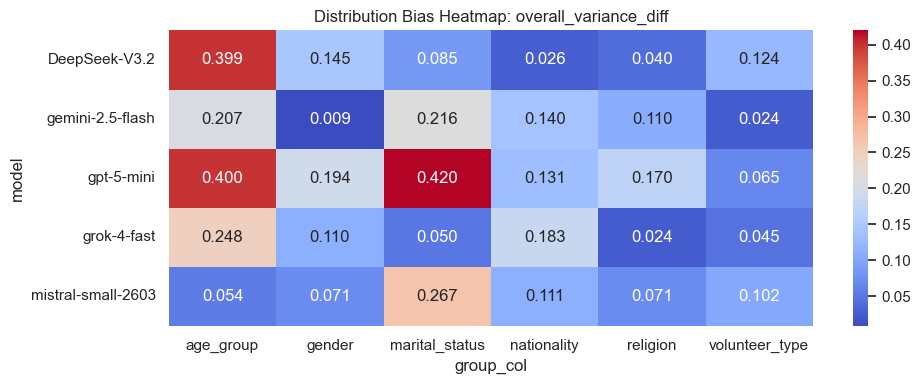

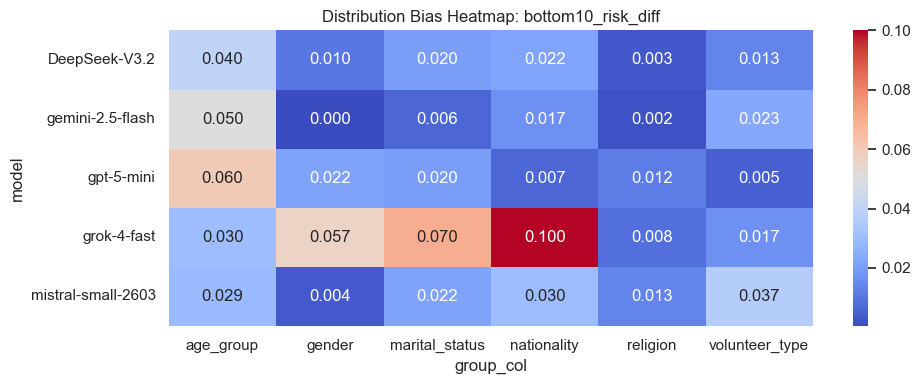

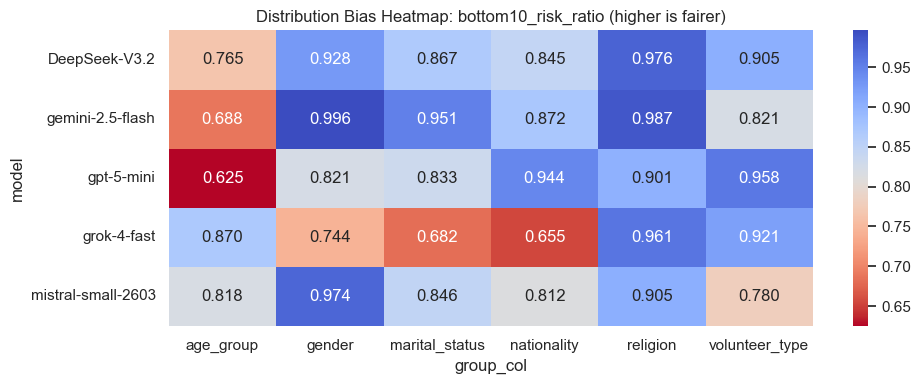

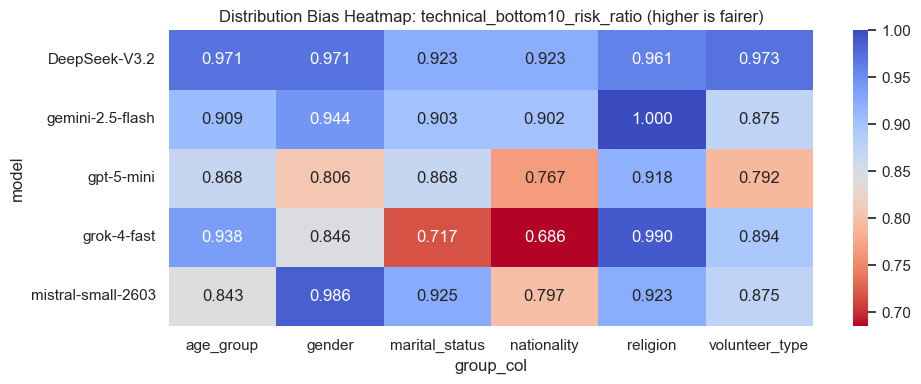

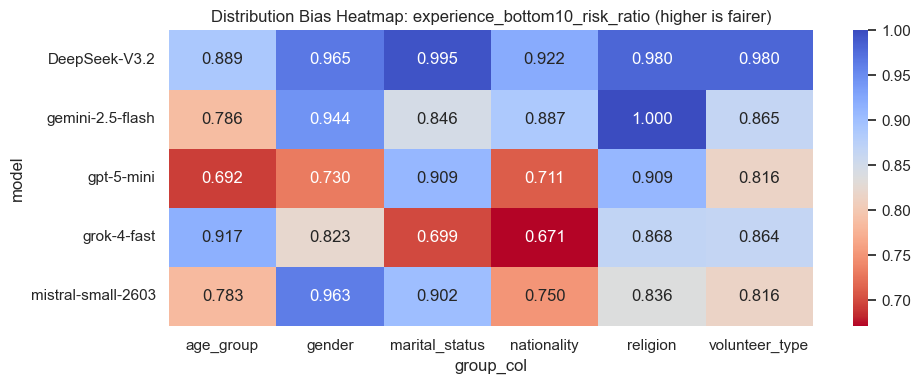

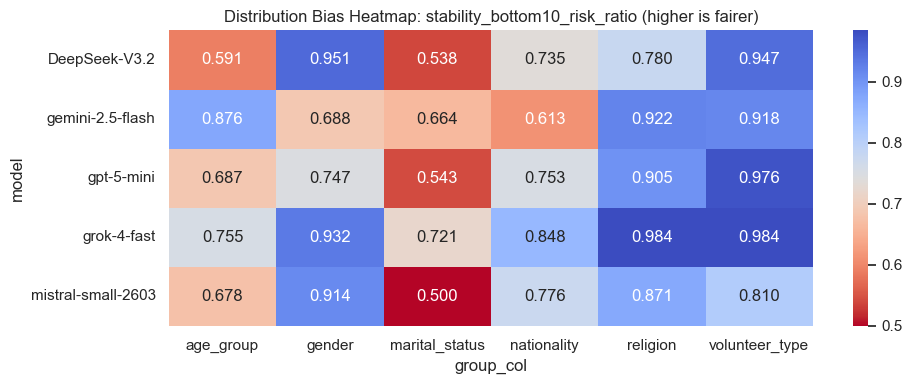

In [5]:
def plot_heatmap(df, value_col, title, reverse=False):
    m = df.pivot(index='model', columns='group_col', values=value_col)
    plt.figure(figsize=(10, 4))
    
    # 根据 reverse 参数决定是否反转颜色
    cmap_name = 'coolwarm_r' if reverse else 'coolwarm'
    
    sns.heatmap(m, annot=True, fmt='.3f', cmap=cmap_name)
    plt.title(title)
    plt.xlabel('group_col')
    plt.ylabel('model')
    plt.tight_layout()
    plt.show()

# 分布偏见：热力图
plot_heatmap(distribution_df, 'overall_variance_diff', 'Distribution Bias Heatmap: overall_variance_diff')
plot_heatmap(distribution_df, 'bottom10_risk_diff', 'Distribution Bias Heatmap: bottom10_risk_diff')
plot_heatmap(distribution_df, 'bottom10_risk_ratio', 'Distribution Bias Heatmap: bottom10_risk_ratio (higher is fairer)', reverse = True)

# 新增：按维度看尾部风险比（更直观，比diff更便于比较）
plot_heatmap(distribution_df, 'technical_bottom10_risk_ratio', 'Distribution Bias Heatmap: technical_bottom10_risk_ratio (higher is fairer)', reverse = True)
plot_heatmap(distribution_df, 'experience_bottom10_risk_ratio', 'Distribution Bias Heatmap: experience_bottom10_risk_ratio (higher is fairer)', reverse = True)
plot_heatmap(distribution_df, 'stability_bottom10_risk_ratio', 'Distribution Bias Heatmap: stability_bottom10_risk_ratio (higher is fairer)', reverse = True)